In [1]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "DesyneMartinez"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("STAT-7110-Quality-Control//Assignments//HW1")

## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

The purpose of this analysis is to investigate Extruder Line 3 which is the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control and why the filament diameter produced in milimeters is causing clogging, stringing, and inconsistent print layers according to consumers.

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.

The quality characteristic we will monitor is the Filament diameter. This is measured in milimeters and is a continuous variable with numeric data.

### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

Since we are monitoring a continuous variable,
which is the filament diameter we are intereseted in two things the Process location
and the Process variability. We want to ensure that the average filament diameter is the same and if the spread of the filament diameter is stable. A skewhart chart would be the best to use in this situation but we need to keep in mind that the variation would need to be stable, so things like human interaction, tools, and material changes might not be detected in the chart.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…
Standard Deviation from qcc: 0.01144864 
Center line from qcc: 0.02662954 


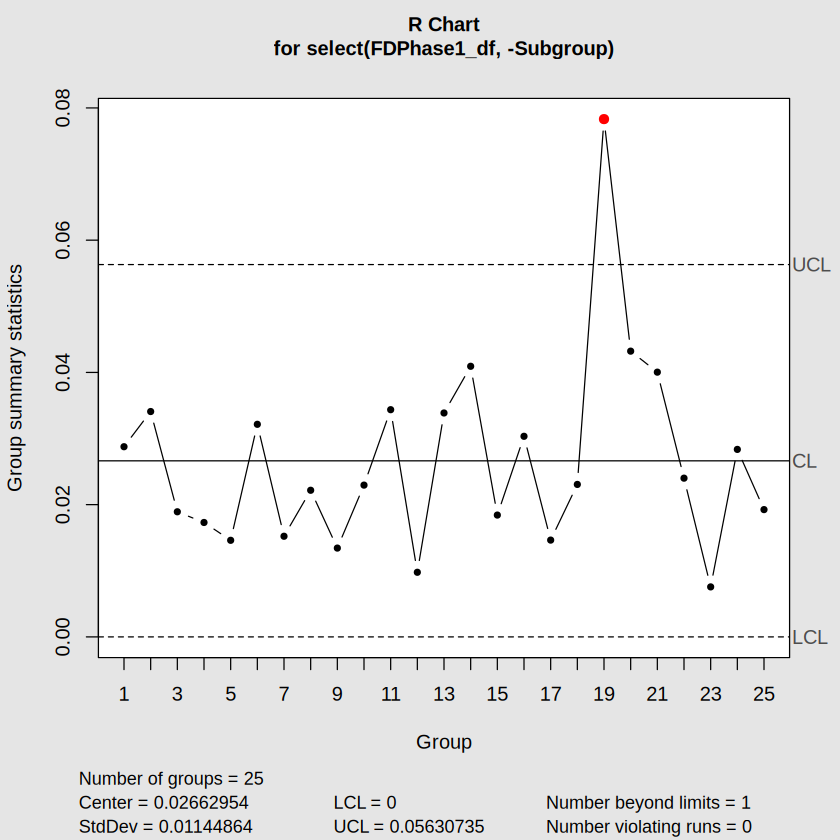

Standard Deviation from qcc: 0.01154485 
Center line from qcc: 0.01085199 


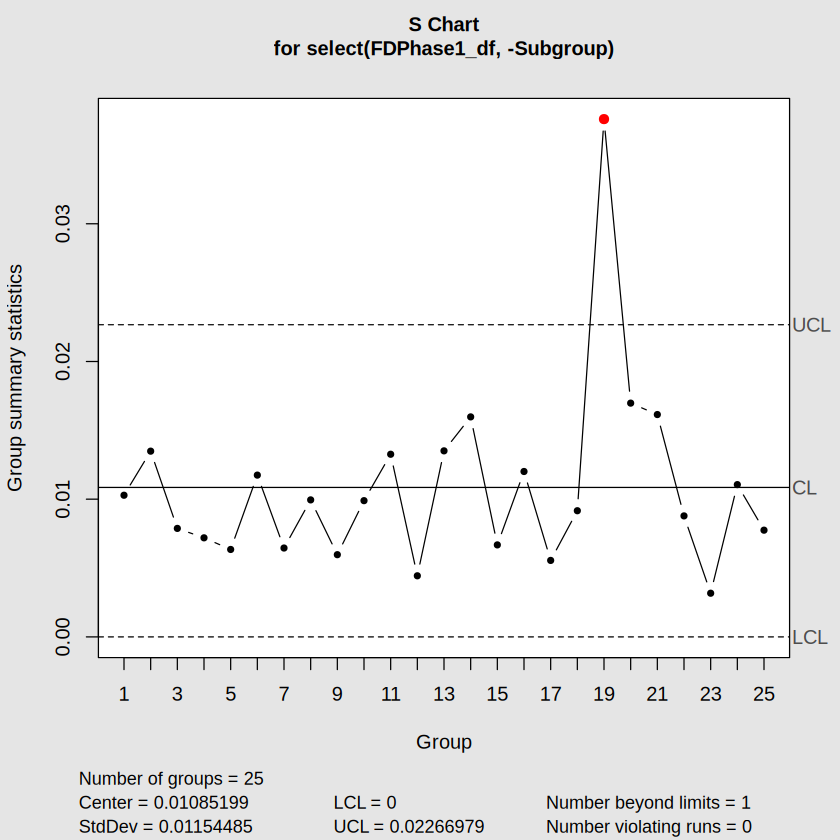

In [3]:
## Q4 Code ##

## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Wafer Data ##

FDPhase1_df <- read_excel("FilamentDiameter_PhaseI.xlsx")

## Data Integrity Check ##

FDPhase1_df |>
  glimpse()


phase1_r <- qcc(FDPhase1_df |> select(-`Subgroup`),
                 type = "R",
                 plot = TRUE)


center_line <- phase1_r$center

stdR <- phase1_r$std.dev
cat("Standard Deviation from qcc:", stdR, "\n")
cat("Center line from qcc:", center_line, "\n")

phase1_s <- qcc(FDPhase1_df |> select(-`Subgroup`),
                 type = "S",
                 plot = TRUE)

 center_lines <- phase1_s$center

stdS <- phase1_s$std.dev
cat("Standard Deviation from qcc:", stdS, "\n")
cat("Center line from qcc:", center_lines, "\n")



### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

List of 11
 $ call      : language qcc(data = select(FDPhase1_df, -Subgroup), type = "R", plot = TRUE)
 $ type      : chr "R"
 $ data.name : chr "select(FDPhase1_df, -Subgroup)"
 $ data      : num [1:25, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.0288 0.0341 0.0189 0.0173 0.0146 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0266
 $ std.dev   : num 0.0114
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0563
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

$beyond.limits
[1] 19

$violating.runs
numeric(0)

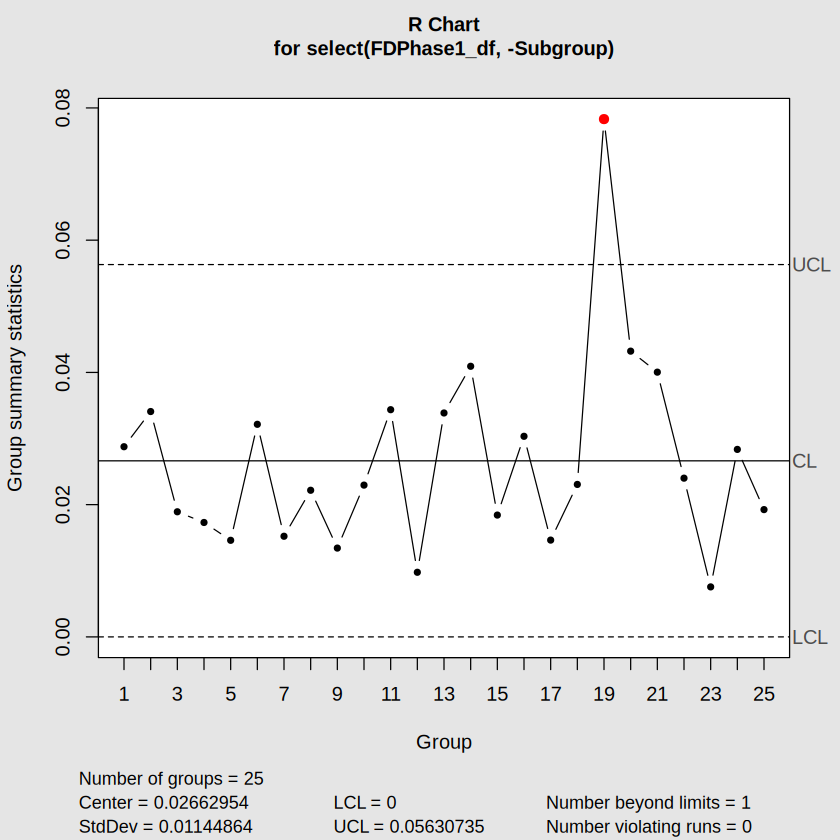

In [5]:
## Q5 Code ##


phase1_r <- qcc(FDPhase1_df |> select(-`Subgroup`),
                 type = "R",
                 plot = TRUE)
                 (phase1_r)

phase1_r$violations

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

In [ ]:
## Q6 Code ##

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

In [ ]:
## Q7 Code ##

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [ ]:
## Q8 Code ##

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

In [ ]:
## Q10 Code ##

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

In [ ]:
## Q11 Code ##

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?